In [ ]:
import cv2
import numpy as np
import os
from glob import glob
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import matplotlib.pyplot as plt

def process_single_image(file_info):
    path, save_path, size = file_info
    
    try:
        # 1. Load
        img = cv2.imread(path)
        if img is None: return
        
        # 2. FAST CROP (Remove black frame)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest)
            if w > 10 and h > 10:
                img = img[y:y+h, x:x+w]

        # 3. TEXTURE-PRESERVING HAIR REMOVAL (Dull Razor)
        # We process at the current resolution to keep the hair mask precise
        gray_crop = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Blackhat highlights dark hair on lighter skin
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
        blackhat = cv2.morphologyEx(gray_crop, cv2.MORPH_BLACKHAT, kernel)
        
        # Create a precise mask (thresholding the blackhat)
        _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
        
        # Refine mask: remove tiny noise that might be skin texture
        mask = cv2.medianBlur(mask, 3) 
        
        # Inpaint with a tiny radius (1) to prevent smudging neighboring pixels
        # Using INPAINT_NS (Navier-Stokes) which tends to preserve edges better
        img = cv2.inpaint(img, mask, 1, cv2.INPAINT_NS)

        # 4. HIGH-FIDELITY RESIZE
        # We resize AFTER hair removal so the mask aligns perfectly with the hair pixels
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_LANCZOS4)

        # 5. Save
        cv2.imwrite(save_path, img)
        
    except Exception as e:
        print(f"Error processing {path}: {e}")

Testing processing on one image...


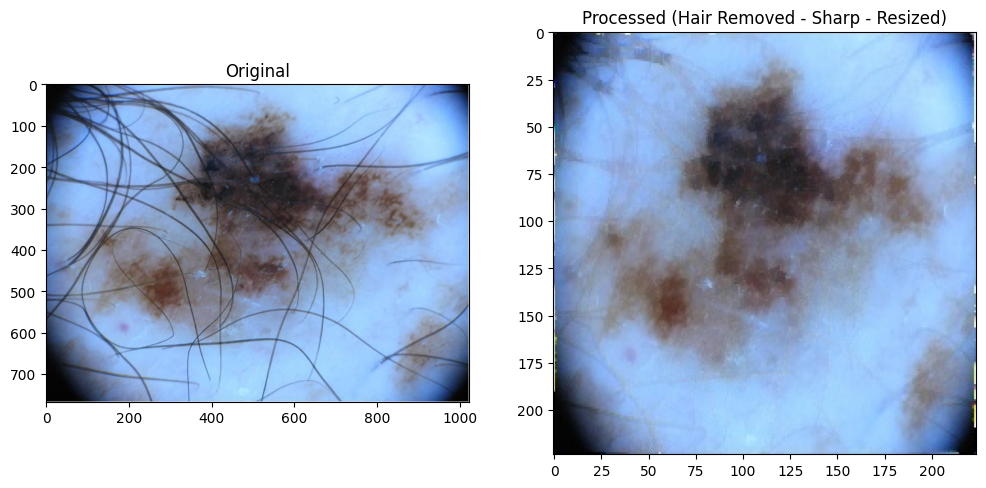

100%|██████████| 17060/17060 [37:45<00:00,  7.53it/s]

DONE


In [ ]:
if __name__ == "__main__":
    INPUT_FOLDER = "/kaggle/input/datasets/minchou01/dicm-17k/images/"
    OUTPUT_FOLDER = "final_processed_images/"
    TARGET_SIZE = 224
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)
    
    # Test on one image
    test_path = os.path.join(INPUT_FOLDER, "ISIC_0000074.jpg")
    if os.path.exists(test_path):
        print("Testing processing on one image...")
        test_output = os.path.join(OUTPUT_FOLDER, "test_processing.jpg")
        process_single_image((test_path, test_output, TARGET_SIZE))
        
        # Display comparison
        original = cv2.cvtColor(cv2.imread(test_path), cv2.COLOR_BGR2RGB)
        processed = cv2.cvtColor(cv2.imread(test_output), cv2.COLOR_BGR2RGB)
        
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        ax[0].imshow(original)
        ax[0].set_title("Original")
        ax[1].imshow(processed)
        ax[1].set_title("Processed (Hair Removed - Sharp - Resized)")
        plt.show()

    all_files = glob(os.path.join(INPUT_FOLDER, "*.jpg"))
    tasks = [(p, os.path.join(OUTPUT_FOLDER, os.path.basename(p)), TARGET_SIZE) for p in all_files]

    with ProcessPoolExecutor() as executor:
        list(tqdm(executor.map(process_single_image, tasks), total=len(tasks)))

    print("DONE")